In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind

In [162]:
df = pd.read_csv("world_happiness_dataset.csv", index_col=0)

In [163]:
df.head()

,country,social_support,freedom,corruption,generosity,gdp_per_cap,life_exp,happiness_score
1,Finland,2.0,5.0,4.0,47.0,42400,81.8,155
2,Denmark,4.0,6.0,3.0,22.0,48300,81.0,154
3,Norway,3.0,3.0,8.0,11.0,66300,82.6,153
4,Iceland,1.0,7.0,45.0,3.0,47900,83.0,152
5,Netherlands,15.0,19.0,12.0,7.0,50500,81.8,151


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 143 entries, 1 to 143
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          143 non-null    object 
 1   social_support   142 non-null    float64
 2   freedom          142 non-null    float64
 3   corruption       135 non-null    float64
 4   generosity       142 non-null    float64
 5   gdp_per_cap      143 non-null    int64  
 6   life_exp         143 non-null    float64
 7   happiness_score  143 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 10.1+ KB


In [165]:
df.describe()

,social_support,freedom,corruption,generosity,gdp_per_cap,life_exp,happiness_score
count,142.000000,142.000000,135.000000,142.00000,143.000000,143.000000,143.000000
mean,77.352113,77.000000,73.244444,78.78169,20124.286713,73.796503,77.643357
std,45.743379,45.569058,42.237507,44.87921,20570.547556,7.092194,46.377418
min,1.000000,1.000000,1.000000,1.00000,631.000000,52.900000,0.000000
25%,37.250000,37.500000,37.500000,41.25000,4110.000000,69.100000,36.500000
50%,76.000000,75.500000,74.000000,80.50000,13000.000000,74.900000,79.000000
75%,116.750000,116.750000,109.500000,116.75000,29750.000000,79.650000,118.000000
max,155.000000,155.000000,148.000000,155.00000,113000.000000,85.100000,155.000000


## Task 1

In [166]:
happiness_mean = df.happiness_score.mean()
happiness_median = df.happiness_score.median()
happiness_std = df.happiness_score.std()

print(f"Mean happiness: {happiness_mean}")
print(f"Median happiness: {happiness_median}")
print(f"Happiness standard deviation: {happiness_std}")

Mean happiness: 77.64335664335664
Median happiness: 79.0
Happiness standard deviation: 46.37741764616525


## Task 2

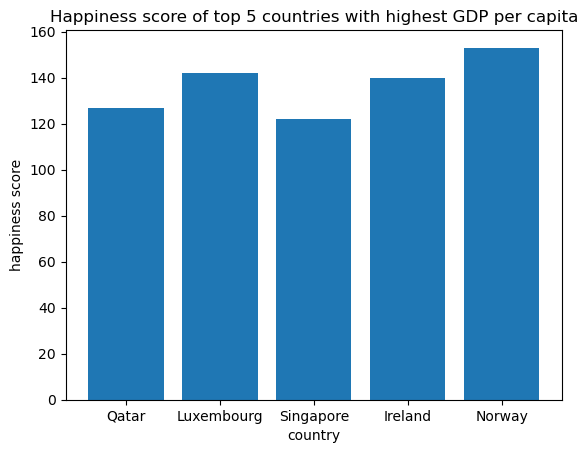

In [167]:
gdp_top5 = df.sort_values(by=["gdp_per_cap"], ascending=False).head(5)

plt.bar(gdp_top5.country, gdp_top5.happiness_score)
plt.ylabel("happiness score")
plt.xlabel("country")
plt.title("Happiness score of top 5 countries with highest GDP per capita")
plt.show()

## Task 3

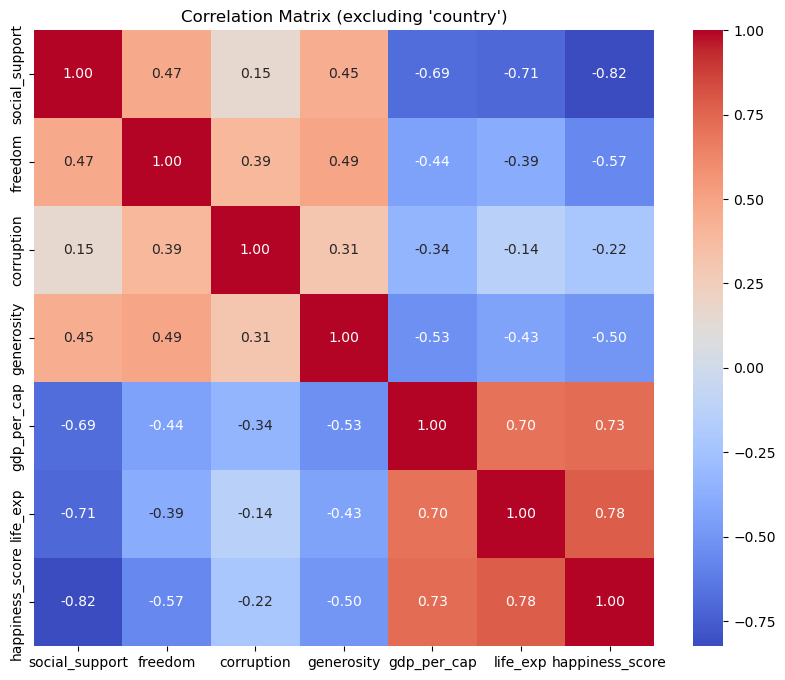

In [168]:
corr_matrix = df.loc[:, df.columns != "country"].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (excluding 'country')")
plt.show()

## Task 4

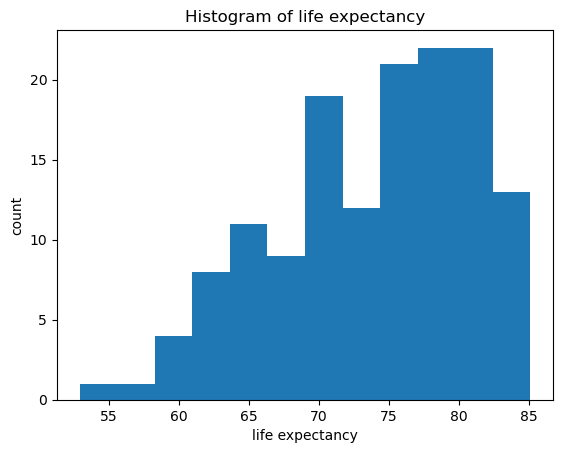

In [169]:
plt.hist(df.life_exp, bins=12)
plt.xlabel("life expectancy")
plt.ylabel("count")
plt.title("Histogram of life expectancy")
plt.show()

# largest values for 70 and around 80
# a drop for 70-75
# small values for 60-70
# only one country with values less than around 60
# the largest values is 85

## Task 5

In [170]:
social_support_threshold = 50

social_support = df.social_support[df.social_support.notna()]
social_support_count = (social_support > social_support_threshold).sum()
social_support_total = len(social_support)
social_support_prob = social_support_count/social_support_total
print(f"Probability of selecting a country with social support > 50 is {social_support_prob}")

Probability of selecting a country with social support > 50 is 0.6690140845070423


## Task 6

In [171]:
# assumption: life_exp normally distributed

life_exp_threshold = 80

life_exp = df.life_exp[df.life_exp.notna()]
life_exp_mean = life_exp.mean()
life_exp_std = life_exp.std()

# P(X > 80) = 1 - F_X(80) = 1 - F((80 - mean) / std)

life_exp_threshold_norm = (life_exp_threshold - life_exp_mean) / life_exp_std

life_exp_prob = 1 - norm.cdf(life_exp_threshold_norm)

print(f"Probability that a country has life expectancy greater then 80 is {life_exp_prob}")

Probability that a country has life expectancy greater then 80 is 0.1908703229127775


## Task 7

In [172]:
gdp_per_cap = df[["gdp_per_cap"]]
happiness_score = df.happiness_score
lr1 = LinearRegression()
lr1.fit(gdp_per_cap, happiness_score)

happiness_score_pred = lr1.predict(gdp_per_cap)

mse_train1 = mean_squared_error(happiness_score, happiness_score_pred)
print(f"Training error: {mse_train1}")

Training error: 1003.9544100372476


## Task 8

In [173]:
df1 = df[["gdp_per_cap", "life_exp", "freedom", "social_support", "happiness_score"]].dropna()
X = df1.loc[:, df1.columns != "happiness_score"]
y = df1.happiness_score
lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

mse_train = mean_squared_error(y, y_pred)
print(f"Training error: {mse_train}")

Training error: 421.91097896991323


## Task 9

In [174]:
social_support_median = df.social_support.median()
life_exp1 = df.loc[df.social_support > social_support_median, "life_exp"]
life_exp2 = df.loc[df.social_support <= social_support_median, "life_exp"]

t_stat, p_value = ttest_ind(life_exp1, life_exp2)
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
# so there is a significant difference, p-value < 0.05

t-statistic = -8.834, p-value = 0.0000


## Task 10

In [175]:
life_exp_threshold1 = 80
happiness_score1 = df.loc[df.life_exp > life_exp_threshold1, "happiness_score"]
happiness_score2 = df.loc[df.life_exp <= life_exp_threshold1, "happiness_score"]

t_stat, p_value = ttest_ind(happiness_score1, happiness_score2)
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
# so there is a significant difference, p-value < 0.05

t-statistic = 8.980, p-value = 0.0000
